In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from CLEAR_line import get_Quad_K_from_I



RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [12]:
def plot_vs_x(
    df,
    x_col,
    y_cols,
    err_cols=None,
    y_labels=None,
    group_col="beam_type",
    groups=("col", "uncol"),
    markers=("o", "s"),
    min_vals=None,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=(8, 5),
):
    if isinstance(y_cols, str):
        y_cols = [y_cols]
    if err_cols is None:
        err_cols = [None] * len(y_cols)
    elif isinstance(err_cols, str):
        err_cols = [err_cols]
    if y_labels is None:
        y_labels = y_cols
    if min_vals is None:
        min_vals = [None] * len(y_cols)
    elif not isinstance(min_vals, (list, tuple)):
        min_vals = [min_vals] * len(y_cols)

    # NEW: no grouping -> single pass over the whole dataframe
    if group_col is None:
        groups = [None]

    plt.figure(figsize=figsize)

    for group in groups:
        sub = df if group is None else df[df[group_col] == group]

        for y_col, err_col, y_label, marker, min_val in zip(
            y_cols, err_cols, y_labels, markers, min_vals
        ):
            plot_data = sub if min_val is None else sub[sub[y_col] > min_val]

            yerr = plot_data[err_col] if err_col is not None else None
            label = y_label if group is None else f"{group} {y_label}"
            plt.errorbar(
                plot_data[x_col], plot_data[y_col],
                yerr=yerr,
                marker=marker, capsize=4, linestyle="--",
                label=label
            )

    plt.xlabel(xlabel or x_col.capitalize())
    plt.ylabel(ylabel or "")
    plt.title(title or f"Evolution with {x_col}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
kind = "YAG"
# Load CSV

if kind == "YAG":
    df = pd.read_csv("CLEAR_experiments/May2026/quad_scan_YAG_large_orig.csv")
    # Extract magnet number and current from folder name
    df[["magnet", "current"]] = df["folder"].str.extract(
        r"_(?:col|uncol)_(\d+)_([0-9]+)A"
    ).astype(float)



# Sort for cleaner line plots
df = df.sort_values(["magnet", "current"])
df



,folder,cx,cy,CD_centre,P_x,P_y,r90_x,r90_y,ratio_x,ratio_y,CD_std,errPx,errPy,err_x90_x,err_x90_y,charge_after_bgnd_pC,magnet,current
0,FLASH_single_45mm_uncol_760_10A,425,463,0.355326,1.000000,1.978749,2.592513,6.501152,0.018386,1.171334,0.023431,0.010658,0.030670,0.033202,0.062054,0.155766,760.0,10.0
1,FLASH_single_45mm_uncol_760_20A,415,454,0.272655,1.000000,2.442673,2.518590,7.749669,0.014209,1.274663,0.022563,0.012916,0.073144,0.038925,0.116447,0.132889,760.0,20.0
2,FLASH_single_45mm_uncol_760_30A,400,452,0.209978,1.000000,2.632623,2.517575,8.293160,0.010214,1.290120,0.017680,0.018891,0.068434,0.056995,0.101001,0.107196,760.0,30.0
3,FLASH_single_45mm_uncol_760_40A,391,455,0.173029,1.000000,2.639164,2.498661,8.557602,0.009797,1.280202,0.015577,0.018476,0.064309,0.055378,0.098586,0.090917,760.0,40.0
4,FLASH_single_45mm_uncol_760_50A,377,457,0.152413,1.000000,2.530807,2.456918,8.514102,0.009669,1.237140,0.013817,0.017716,0.052369,0.052339,0.087902,0.079539,760.0,50.0
5,FLASH_single_45mm_uncol_765_10A,438,465,0.397455,1.347991,1.125080,4.177733,3.253592,0.921215,0.733230,0.024833,0.017026,0.011666,0.048436,0.035854,0.154185,765.0,10.0
6,FLASH_single_45mm_uncol_765_20A,444,515,0.302817,2.172659,1.270849,5.980154,4.577608,1.026462,0.882882,0.019101,0.061856,0.012523,0.095183,0.045465,0.153081,765.0,20.0
7,FLASH_single_45mm_uncol_765_30A_kicked,463,500,0.299205,1.000000,2.237475,3.655176,6.929573,1.114031,1.210726,0.022541,0.022242,0.053706,0.116123,0.090261,0.152458,765.0,30.0
8,FLASH_single_45mm_uncol_765_40A_kicked,452,492,0.275876,1.214793,2.882125,3.737370,8.482199,1.134641,1.307192,0.021280,0.022074,0.068626,0.070105,0.085606,0.156005,765.0,40.0
9,FLASH_single_45mm_uncol_765_50A_kicked,470,474,0.230108,1.000000,3.121559,3.376709,9.045451,1.152810,1.318874,0.018245,0.019832,0.071746,0.091609,0.081569,0.138098,765.0,50.0


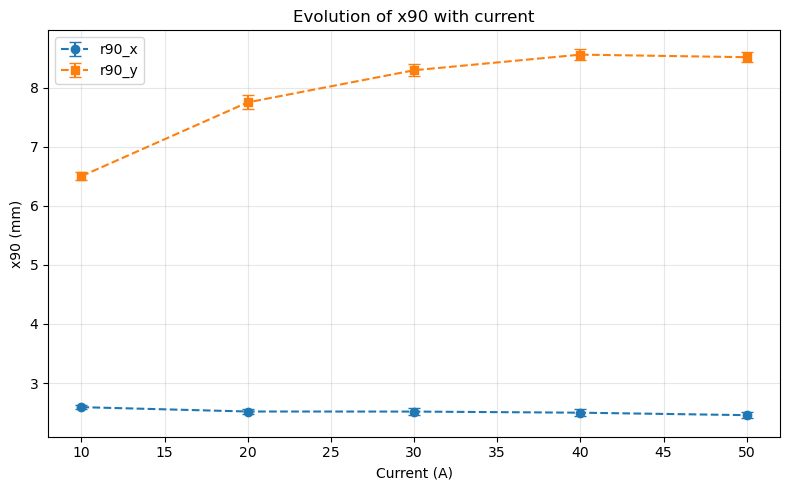

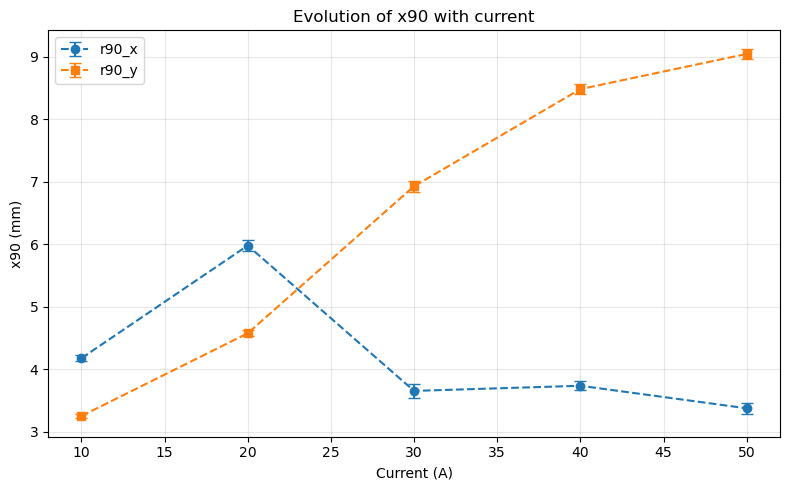

In [14]:
# -------------------------
# Plot 1: r90_x and r90_y
# -------------------------
df_760 = df[df["magnet"] == 760]
df_765 = df[df["magnet"] == 765]

for i in eval("df_760, df_765"):
    plot_vs_x(
        i, x_col="current",
        y_cols=["r90_x", "r90_y"],
        group_col=None,
        groups=None,
    err_cols=["err_x90_x", "err_x90_y"],
    ylabel="x90 (mm)",
    xlabel="Current (A)",
    title="Evolution of x90 with current"
)



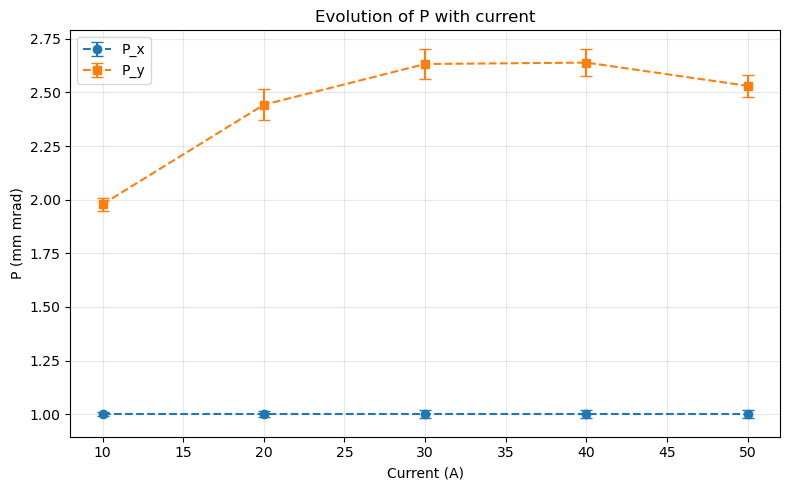

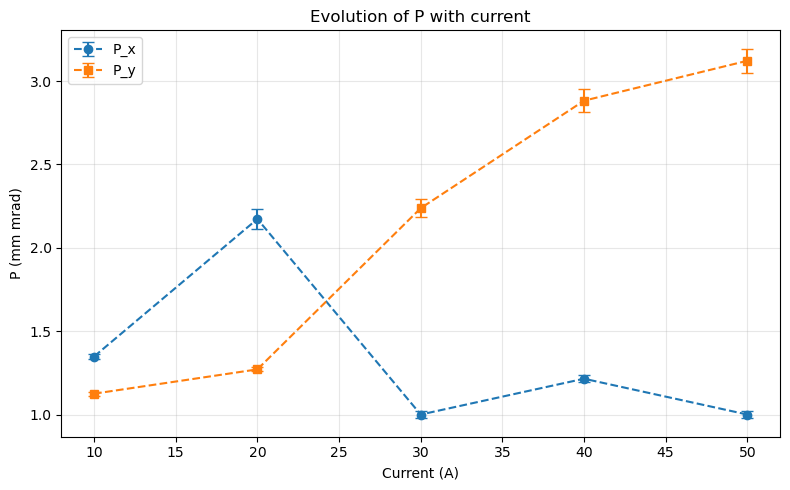

In [16]:
# -------------------------
# Plot 2: P_x and P_y
# -------------------------
for i in eval("df_760, df_765"):
    plot_vs_x(
        i, x_col="current",
        y_cols=["P_x", "P_y"],
        group_col=None,
        groups=None,
    err_cols=["errPx", "errPy"],
    ylabel="P (mm mrad)",
    xlabel="Current (A)",
    title="Evolution of P with current"
)

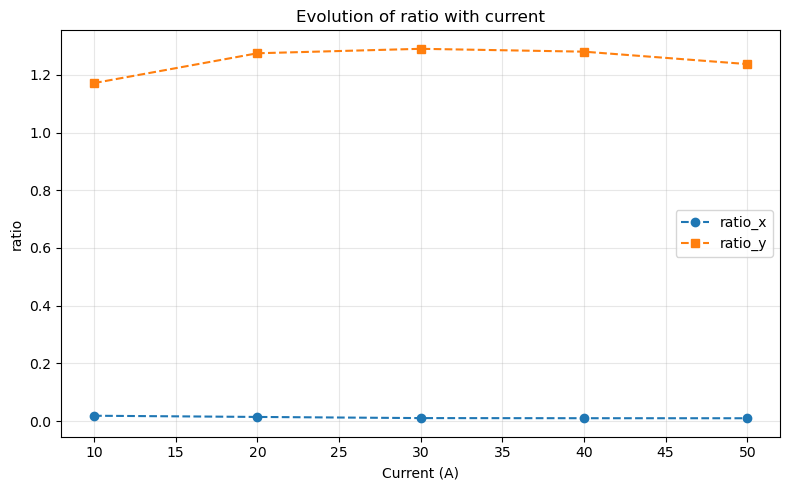

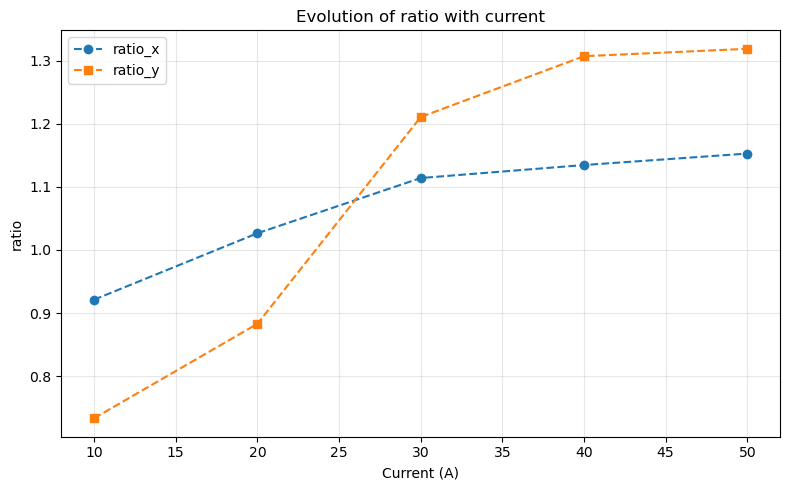

In [17]:
# -------------------------
# Plot 3: ratio_x and ratio_y
# -------------------------
for i in eval("df_760, df_765"):
    plot_vs_x(
        i, x_col="current",
        y_cols=["ratio_x", "ratio_y"],
        group_col=None,
        groups=None,
    ylabel="ratio",
    xlabel="Current (A)",
    title="Evolution of ratio with current"
)

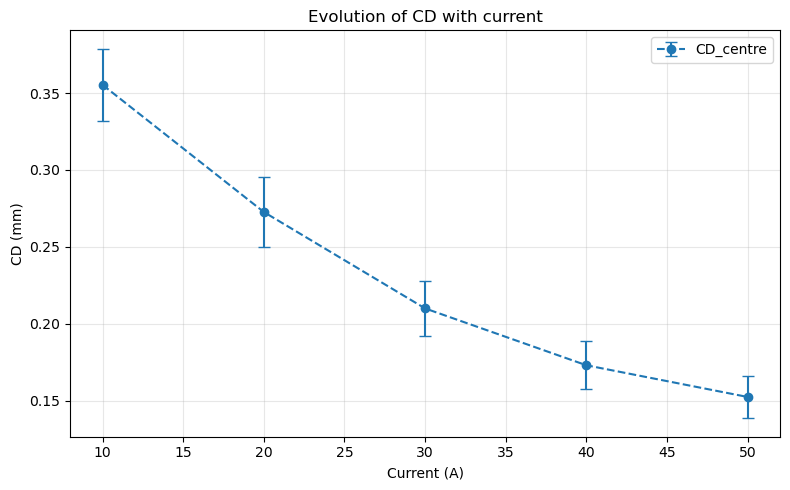

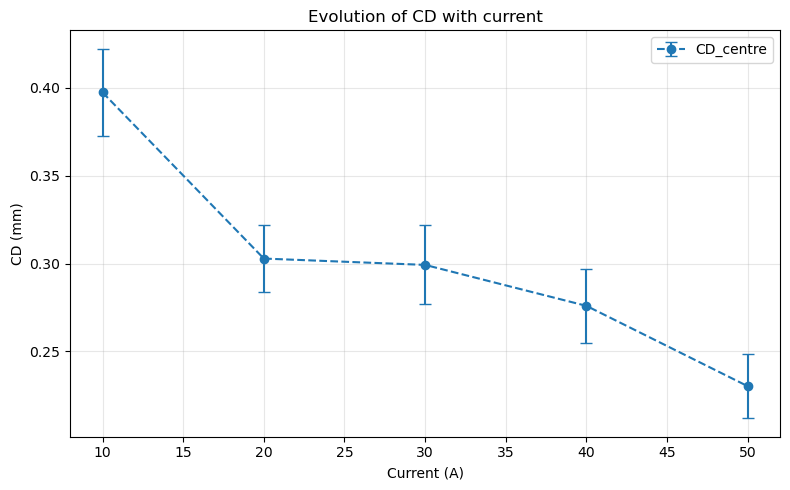

In [19]:
# -------------------------
# Plot 4: CD
# -------------------------

for i in eval("df_760, df_765"):
    plot_vs_x(
        i, x_col="current",
        y_cols=["CD_centre"],
        err_cols=["CD_std"],
        group_col=None,
        groups=None,
    ylabel="CD (mm)",
    xlabel="Current (A)",
    title="Evolution of CD with current"
)

starting analysis for 875 screen scans

In [4]:
csv_path = "CLEAR_experiments/May2026/quad_scan875_small.csv"
energy = 197.3 #MeV

df_875 = pd.read_csv(csv_path)
df_875

,file,magnet,current,s1in,sigma_x,sigma_y
0,scan765_I_61_s1in.pkl,765,61.0,True,1.805212,2.118764
1,scan765_I_61.pkl,765,61.0,False,1.463621,1.785540
2,scan765_I_62_s1in.pkl,765,62.0,True,1.737318,1.881151
3,scan765_I_62.pkl,765,62.0,False,1.342615,1.448477
4,scan765_I_63_s1in.pkl,765,63.0,True,1.698234,1.632268
5,scan765_I_63.pkl,765,63.0,False,1.326978,1.133577
6,scan765_I_64.pkl,765,64.0,False,1.302637,0.843865
7,scan765_I_64_s1in.pkl,765,64.0,True,1.675738,1.462316
8,scan765_I_65.pkl,765,65.0,False,1.356010,0.689405
9,scan765_I_65_s1in.pkl,765,65.0,True,1.684104,1.379453


In [5]:

def quad_scan_emittance_thinlens(fit_coeffs, d, l, energy=None):
    """
   
    https://indico.cern.ch/event/703517/contributions/2886144/attachments/
    1602810/2541739/2018-02-19_Emittance_measurement_with_quadrupole_scan.pdf

    IMPORTANT: fit_coeffs must come from
    i.e. coeffs = np.polyfit(k, sigma**2, deg=2)

    Parameters
    ----------
    fit_coeffs : array-like, length 3
        [A, B, C] coefficients of the parabola fit:
            sigma_sem^2(k) = A*k^2 + B*k + C
        (this is exactly what np.polyfit(k, sigma**2, deg=2) returns)
    d : float
        Drift length between quadrupole and screen/monitor [m]
    l : float
        Effective quadrupole length [m]

    Returns
    -------
    dict with keys:
        'sigma11_quad', 'sigma12_quad', 'sigma22_quad' : beam matrix elements at quad
        'emittance'      : geometric emittance [m·rad]
        'alpha', 'beta', 'gamma' : Twiss parameters at the quad entrance
        'emittance_n'    : normalized emittance [m·rad] (only if beta_rel/gamma_rel given)
    """
    A, B, C = fit_coeffs

    # Invert to get the beam matrix elements at the quadrupole (P0)
    sigma11_quad = A / (d**2 * l**2)
    sigma12_quad = (B - 2 * d * l * sigma11_quad) / (2 * d**2 * l)
    sigma22_quad = (C - sigma11_quad - 2 * d * sigma12_quad) / d**2

    # Geometric emittance: eps^2 = sigma11*sigma22 - sigma12^2
    eps_sq = sigma11_quad * sigma22_quad - sigma12_quad**2
    if eps_sq < 0:
        raise ValueError(
            "Negative value under sqrt for emittance "
            f"(sigma11*sigma22 - sigma12^2 = {eps_sq:.3e}). "
            "Check fit quality, sign of k, or units of d/l."
        )
    emittance = np.sqrt(eps_sq)

    # Twiss parameters at the quad location
    alpha = -sigma12_quad / emittance
    beta = sigma11_quad / emittance
    gamma = sigma22_quad / emittance

    result = {
        "sigma11_quad": sigma11_quad,
        "sigma12_quad": sigma12_quad,
        "sigma22_quad": sigma22_quad,
        "emittance": emittance,
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
    }

    if energy is not None:
        beta_rel = np.sqrt(1 - (0.511 / energy)**2)  # MeV/c^2 for electron rest mass
        gamma_rel = energy / 0.511  # MeV/c^2 for electron
        result["emittance_n"] = beta_rel * gamma_rel * emittance

    return result

In [6]:
def _quad_drift_matrix(k, L, d):
    """
    Build the transfer matrix M = Drift(d) @ Quad(k, L) for a single k value,
    using the sign convention: k > 0 -> focusing plane (trig functions),
    k < 0 -> defocusing plane (hyperbolic functions), following
    https://web.mit.edu/22.09/ClassHandouts/Charged%20Particle%20Accel/CHAP08.PDF

    Parameters
    ----------
    k : float
        Signed quadrupole strength [m^-2] for this plane.
    L : float
        Effective quadrupole (magnetic) length [m].
    d : float
        Drift length from quad exit to screen [m].

    Returns
    -------
    M11, M12 : float
        Top row of the combined 2x2 transfer matrix (that's all we need,
        since sigma_sem^2 only depends on M11 and M12).
    """
    if k > 0:
        # Focusing plane
        sqk = np.sqrt(k)
        c = np.cos(sqk * L)
        s = np.sin(sqk * L)
        q11, q12 = c, s / sqk
        q21 = -sqk * s
    elif k < 0:
        # Defocusing plane
        sqk = np.sqrt(-k)
        c = np.cosh(sqk * L)
        s = np.sinh(sqk * L)
        q11, q12 = c, s / sqk
        q21 = sqk * s
    else:
        # k == 0: quad off -> pure drift over length L
        q11, q12 = 1.0, L
        q21 = 0.0

    # Quad matrix: [[q11, q12], [q21, q22=q11 (symmetric for these forms)]]
    # Drift matrix: [[1, d], [0, 1]]
    # Combined M = Drift @ Quad
    M11 = q11 + d * q21
    M12 = q12 + d * q11
    return M11, M12


def quad_scan_emittance_thick(k, sigma, L, d, energy=None):
    """
    Compute Twiss parameters and emittance from a quadrupole scan using the
    thick-lens quadrupole transfer matrix (exact, not thin-lens approximation).

    Parameters
    ----------
    k : array-like
        Signed quadrupole strengths [m^-2] for each scan point
        (k > 0 = focusing in this plane, k < 0 = defocusing).
    sigma : array-like
        Measured beam sizes [m] at the screen for each k (NOT squared --
        this function squares them internally).
    L : float
        Effective quadrupole length [m].
    d : float
        Drift length from quad exit to screen [m].
    beta_rel, gamma_rel : float, optional
        Relativistic beta and gamma of the beam, for normalized emittance.

    Returns
    -------
    dict with the same keys as quad_scan_emittance (sigma11_quad, sigma12_quad,
    sigma22_quad, emittance, alpha, beta, gamma, and emittance_n if requested).
    """
    k = np.asarray(k, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    sigma_sq = sigma**2

    # Build the design matrix: sigma_sem^2 = A*sigma11 + B*sigma12 + C*sigma22
    # where A = M11^2, B = 2*M11*M12, C = M12^2
    design = np.zeros((len(k), 3))
    for i, ki in enumerate(k):
        M11, M12 = _quad_drift_matrix(ki, L, d)
        design[i, 0] = M11**2
        design[i, 1] = 2 * M11 * M12
        design[i, 2] = M12**2

    # Linear least-squares solve for (sigma11_quad, sigma12_quad, sigma22_quad)
    sol, residuals, rank, sv = np.linalg.lstsq(design, sigma_sq, rcond=None)
    sigma11_quad, sigma12_quad, sigma22_quad = sol

    eps_sq = sigma11_quad * sigma22_quad - sigma12_quad**2
    if eps_sq < 0:
        raise ValueError(
            "Negative value under sqrt for emittance "
            f"(sigma11*sigma22 - sigma12^2 = {eps_sq:.3e}). "
            "Check fit quality, sign convention of k, or units of d/L."
        )
    emittance = np.sqrt(eps_sq)

    alpha = -sigma12_quad / emittance
    beta = sigma11_quad / emittance
    gamma = sigma22_quad / emittance

    result = {
        "sigma11_quad": sigma11_quad,
        "sigma12_quad": sigma12_quad,
        "sigma22_quad": sigma22_quad,
        "emittance": emittance,
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
    }

    if energy is not None:
        beta_rel = np.sqrt(1 - (0.511 / energy)**2)  # MeV/c^2 for electron rest mass
        gamma_rel = energy / 0.511  # MeV/c^2 for electron
        result["emittance_n"] = beta_rel * gamma_rel * emittance

    return result

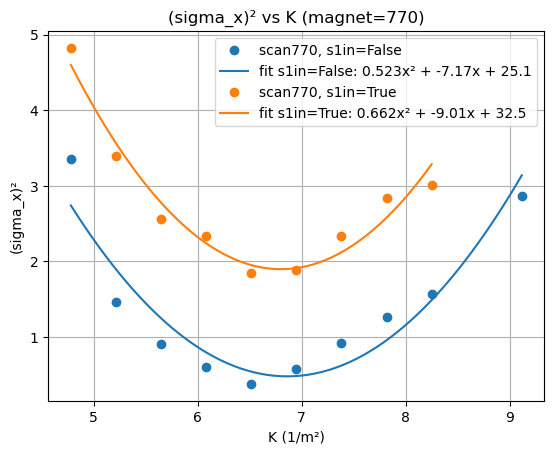

In [7]:
#change beam size to beam size squared

plt.figure()
mask = (df_875["magnet"] == 770) & (df_875["current"] != 100)

for s1in_value, group in df_875.groupby("s1in"):
    group = group.sort_values("current")
    current = group.loc[mask, "current"]
    k = get_Quad_K_from_I(current,0.226,energy)
    sigx = group.loc[mask, "sigma_x"]

    # Plot raw data
    line, = plt.plot(
        k, sigx**2,
        marker="o",
        linestyle="none",
        label=f"scan770, s1in={s1in_value}",
    )

    # Fit and plot quadratic curve
    coeffs = np.polyfit(k, sigx**2, deg=2)
    a, b, c = coeffs
    x_fit = np.linspace(k.min(), k.max(), 200)
    y_fit = np.polyval(coeffs, x_fit)

    plt.plot(
        x_fit, y_fit,
        '-',
        color=line.get_color(),
        label=f"fit s1in={s1in_value}: {a:.3g}x² + {b:.3g}x + {c:.3g}",
    )

plt.xlabel("K (1/m²)")
plt.ylabel("(sigma_x)²")
plt.title("(sigma_x)² vs K (magnet=770)")
plt.legend()
plt.grid(True)
plt.show()

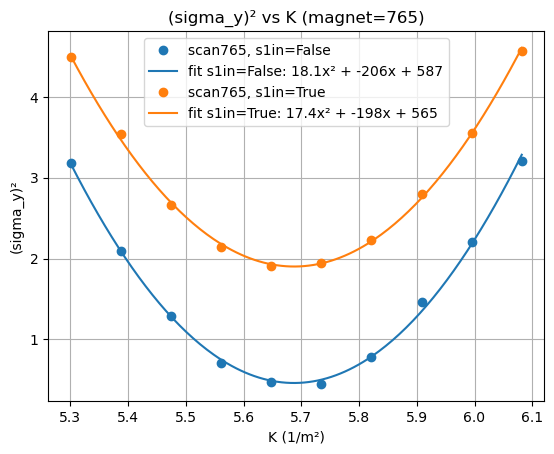

In [8]:
plt.figure()

df_magnet = df_875[df_875["magnet"] == 765]

for s1in_value, group in df_magnet.groupby("s1in"):
    group = group.sort_values("current")
    current = group["current"]
    k = get_Quad_K_from_I(current,0.226,energy)
    sigy = group["sigma_y"]

    # Plot raw data
    line, = plt.plot(
        k, sigy**2,
        marker="o",
        linestyle="none",
        label=f"scan765, s1in={s1in_value}",
    )

    # Fit and plot quadratic curve
    coeffs = np.polyfit(k, sigy**2, deg=2)
    a, b, c = coeffs
    x_fit = np.linspace(k.min(), k.max(), 200)
    y_fit = np.polyval(coeffs, x_fit)

    plt.plot(
        x_fit, y_fit,
        '-',
        color=line.get_color(),
        label=f"fit s1in={s1in_value}: {a:.3g}x² + {b:.3g}x + {c:.3g}",
    )

plt.xlabel("K (1/m²)")
plt.ylabel("(sigma_y)²")
plt.title("(sigma_y)² vs K (magnet=765)")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
magnet = 765

if magnet == 770:
    dist = 0.616 + 2.354 # 616 is distance from end of 840 to 875, then distance between 840 and 770, which is 2.354 m
    
elif magnet == 765:
    dist = 0.616 + 2.804
    
elif magnet == 760:
    dist = 0.616 + 3.254

twiss_results = quad_scan_emittance_thick(k,sigy**2, L=0.226, d=dist, energy=energy) #at end of magnet
twiss_results

{'sigma11_quad': 169.74877916591993,
 'sigma12_quad': 179.24587514766185,
 'sigma22_quad': 189.55877180882263,
 'emittance': 6.948837117652132,
 'alpha': -25.795089467894353,
 'beta': 24.42837215664576,
 'gamma': 27.279207815547505,
 'emittance_n': 2682.97644816013}

In [58]:
twiss_results_thin = quad_scan_emittance_thinlens(coeffs, d=dist, l=0.226, energy=energy)
twiss_results_thin

{'sigma11_quad': 29.13027320749814,
 'sigma12_quad': -45.961895389666736,
 'sigma22_quad': 72.68152207798111,
 'emittance': 2.176411601175076,
 'alpha': 21.11819996036193,
 'beta': 13.384542331868792,
 'gamma': 33.39511792656284,
 'emittance_n': 840.3220522498261}

In [10]:
import numpy as np
from scipy.optimize import curve_fit

from quad_scan_helper import *


def quad_scan_fit_at_reference(
    screen,
    P_ref,
    s_x,
    s_y,
    currents,
    scanned_quad,
    scanned_currents,
    reconstruction_point,
    drift_to_ref,
):
    """
    Fit emittance/Twiss from a quad scan (fitted at `reconstruction_point`,
    upstream of the scanned quad), then report the beam Twiss parameters at
    a reference point located `drift_to_ref` [m] downstream of the exit of
    `scanned_quad`.

    No resolution correction or measurement-uncertainty weighting is applied;
    s_x, s_y are used directly as the beam sizes to fit.

    Parameters
    ----------
    screen : str
        Screen name where the scan was measured (e.g. 'CB.SCR0910').
    P_ref : float
        Reference momentum [MeV/c].
    s_x, s_y : array-like
        Measured beam sizes [m] at the screen, one per scan point.
    currents : array-like, length n_quads
        Fixed current settings for every quad in the lattice (the scanned
        quad's entry is overwritten per scan point using `scanned_currents`).
    scanned_quad : str
        Name of the scanned quadrupole (e.g. 'CA.QFD0770'), must also
        appear in `quad_names` and be a named element in the survey.
    scanned_currents : array-like, length n
        Current setpoints of the scanned quad, one per scan point.
    reconstruction_point : str
        Fixed point upstream of `scanned_quad` where emittance/beta/alpha
        are fitted (must be a named element in the survey).
    drift_to_ref : float
        Drift length [m] from the exit of `scanned_quad` to the reference
        point where you want the reported Twiss parameters.

    Returns
    -------
    dict with:
        'emittance_x', 'emittance_y' : fitted (normalized) emittance, constant over the scan
        'twiss_ref_x', 'twiss_ref_y' : (n, 3) arrays of (beta, alpha, gamma) at the reference point, per scan point
        'chi2_reduced_x', 'chi2_reduced_y'
    """
    s_x = np.asarray(s_x, dtype=float)
    s_y = np.asarray(s_y, dtype=float)
    scanned_currents = np.asarray(scanned_currents, dtype=float)
    n = len(s_x)

    scanned_index = quad_names.index(scanned_quad)

    beta_x_matrix = np.empty((n, 3))
    beta_y_matrix = np.empty((n, 3))
    ref_lattices = []

    for i in range(n):
        quad_currents = np.copy(currents)  # avoid mutating the input array
        quad_currents[scanned_index] = scanned_currents[i]

        # Lattice for the fit: reconstruction_point -> screen
        fit_lattice = get_lattice(reconstruction_point, screen, P_ref, quad_currents)
        beta_x_matrix[i], beta_y_matrix[i] = np.array(fit_lattice.get_twiss_matrix())[:, 0, :]

        # Lattice for the reference point: reconstruction_point -> scanned_quad exit -> drift_to_ref
        ref_lattice = get_lattice(reconstruction_point, scanned_quad, P_ref, quad_currents, include_end=True)
        ref_lattice.append_element(Drift(drift_to_ref))
        ref_lattices.append(ref_lattice)

    g = P_ref/0.511  # Lorentz factor for electrons (MeV/c^2)
    sigma_sq = lambda beta_matrix, emitt, beta, alpha: emitt / g * beta_matrix @ np.array(
        [beta, alpha, (1 + alpha**2) / beta]
    )

    def fit_plane(beta_matrix, s):
        try:
            fit, cov, info = curve_fit(
                f=sigma_sq,
                xdata=beta_matrix,
                ydata=s**2,
                p0=(5, 10, 0),
                full_output=True,
            )[0:3]
            emitt, beta0, alpha0 = fit
            gamma0 = (1 + alpha0**2) / beta0
            chi2 = np.sum(info['fvec']**2)
        except (RuntimeError, ValueError):
            emitt = beta0 = alpha0 = gamma0 = np.nan
            chi2 = np.nan
        return emitt, beta0, alpha0, gamma0, chi2

    emitt_x, beta0_x, alpha0_x, gamma0_x, chi2_x = fit_plane(beta_x_matrix, s_x)
    emitt_y, beta0_y, alpha0_y, gamma0_y, chi2_y = fit_plane(beta_y_matrix, s_y)

    dof = n - 3
    chi2_reduced_x = chi2_x / dof if dof > 0 else np.nan
    chi2_reduced_y = chi2_y / dof if dof > 0 else np.nan

    # Transport fitted Twiss forward to the reference point, per scan setpoint
    twiss_ref_x = np.empty((n, 3))
    twiss_ref_y = np.empty((n, 3))
    twiss_x0 = np.array([beta0_x, alpha0_x, gamma0_x])
    twiss_y0 = np.array([beta0_y, alpha0_y, gamma0_y])

    for i in range(n):
        M_x, M_y = ref_lattices[i].get_twiss_matrix()
        twiss_ref_x[i] = M_x @ twiss_x0
        twiss_ref_y[i] = M_y @ twiss_y0

    return {
        'emittance_x': emitt_x,
        'emittance_y': emitt_y,
        'twiss_ref_x': twiss_ref_x,  # columns: beta, alpha, gamma
        'twiss_ref_y': twiss_ref_y,
        'chi2_reduced_x': chi2_reduced_x,
        'chi2_reduced_y': chi2_reduced_y,
    }

In [12]:
quads_currents = [11,32,22,20,37,16,0,0,0,0,0]


results = quad_scan_fit_at_reference(
    screen='CA.BTV0875',
    P_ref=200,
    s_x=sigx,
    s_y=sigy,
    currents=quads_currents,          # length n_quads, all other quads' fixed settings
    scanned_quad='CA.QDD0765',
    scanned_currents=current,         # length n, the scanned quad's setpoints
    reconstruction_point='CA.QFD0760',
    drift_to_ref=dist)                 # distance from scanned quad exit to reference point

print(results['emittance_x'], results['emittance_y'])
print(results['twiss_ref_x'])


0.00011323258735253633 nan
[[ 9084907.8138232  -2352518.65745869   609179.98807555]
 [ 9200717.00044725 -2383960.24148684   617698.21120623]
 [ 9317400.25616751 -2415648.57103081   626286.07318458]
 [ 9434960.30349485 -2447584.42376159   634943.79613047]
 [ 9553399.86996558 -2479768.57879493   643671.60257909]
 [ 9672721.68814744 -2512201.81669303   652469.71548144]
 [ 9792928.49564553 -2544884.91946624   661338.35820485]
 [ 9914023.03510832 -2577818.67057484   670277.75453344]
 [10036008.05423361 -2611003.85493071   679288.12866867]]
